# Spectral fitting example (NGC 4151)

This notebook fits NGC 4151 using the latest incremental catalog written
by `Source_catalog_generator.ipynb`. NGC 4151 must be present and all catalog
parameters must initially be fixed. The notebook then frees exactly the same
four NGC 4151 parameters for every trial.

Variable-source responses are created only for variable sources that are
actually present in the current catalog. This allows the same fitting notebook
to work for the NGC-4151-only trial and for every cumulative source-addition
trial through the full catalog.


In [1]:
from array import array
import gzip
from pathlib import Path
import sys

import astropy.units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

from astromodels import Cutoff_powerlaw, Parameter, Powerlaw, load_model
from histpy import Histogram
from threeML import DataList, JointLikelihood

from cosipy import BinnedData
from cosipy.background_estimation import FreeNormBinnedBackground
from cosipy.data_io import EmCDSBinnedData
from cosipy.event_selection import GoodTimeInterval
from cosipy.interfaces import ThreeMLPluginInterface
from cosipy.response import (
    BinnedInstrumentResponse,
    BinnedThreeMLModelFolding,
    BinnedThreeMLPointSourceResponse,
)
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.statistics import PoissonLikelihood
from cosipy.threeml.custom_functions import SpecFromDat  # noqa: F401

%matplotlib inline

22:29:50 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=753932;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=16349;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=908612;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=992968;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=909499;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=872604;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

22:29:50 INFO      Starting 3ML!                                                                     ]8;id=834890;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=481628;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

22:29:51 WARNING   WARNINGs here are NOT errors                                                      ]8;id=670971;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=762494;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=654787;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=471337;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=818844;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=667404;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=58032;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=38898;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=269015;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=32035;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=306508;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=323805;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

## Load the FOV-cut data and response

The mock-data and background files below were binned after applying the same 60° NGC 4151 pointing cut used for the spacecraft history.

In [2]:
notebook_dir = Path(
    "/Users/parshadkp/Software/cosipy/docs/tutorials/spectral_fits/continuum_fit/AGN"
)
mock_data_path = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/"
    "DC4_Files/Mock_Data/Mock_Data_Cut/"
    "mock_with_updated_NGC4151_FluxNTH_0p30_time_cut.hdf5"
)
background_path = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/"
    "DC4_Files/Background/"
    "Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_"
    "NGC4151_60deg_fov_cut.hdf5"
)
orientation_path = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/"
    "DC4_Files/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori"
)
response_path = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/"
    "DC4_Files/ResponseContinuum.o3.e100_10000.b10log.s10396905069491."
    "m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5"
)
agn_config = notebook_dir / "agn.yaml"
source_catalog_path = notebook_dir / "source_catalog_DC4_21sources.yaml"
source_library_root = Path(
    "/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library"
)
four_c_21p35_noflare_lc_path = (
    source_library_root
    / "DC3/sources/Extragalactic/4C21p35_noflare/4C_21_lightcurve_noflare.dat"
)
four_c_21p35_flare_lc_path = (
    source_library_root
    / "DC3/sources/Extragalactic/4C21p35_flare/4C_21_lightcurve_flare.dat"
)
maxi_j1820_lc_path = (
    source_library_root
    / "DC3/sources/Galactic/MAXIJ1820/MAXIJ1820_LC.dat"
)
maxi_j1348_lc_path = (
    source_library_root
    / "DC3/sources/Galactic/MAXIJ1348/MAXIJ1348_LC.dat"
)
three_c_454p3_low_lc_path = (
    source_library_root
    / "DC4/sources/Extragalactic/3C454p3_low/3C454p3_low_lightcurve.dat"
)
three_c_454p3_high_lc_path = (
    source_library_root
    / "DC4/sources/Extragalactic/3C454p3_high/3C454p3_high_lightcurve.dat"
)
psr_b1259_lc_path = (
    source_library_root
    / "DC3/sources/Galactic/PSRB1259/PSRB1259_lc.dat"
)
one_rxs_j170849_lc_path = (
    source_library_root
    / "DC4/sources/Galactic/1RXSJ170849/1RXSJ170849_magnetar_lightcurve.dat.gz"
)
generic_magnetar_lc_path = (
    source_library_root
    / "DC4/sources/Galactic/magnetar2/magnetar2_lightcurve.dat.gz"
)
ls_5039_lc_path = (
    source_library_root
    / "DC3/sources/Galactic/LS5039/LS5039_lc.dat"
)
psr_j1846_lc_path = (
    source_library_root
    / "DC3/sources/Galactic/PSRJ1846/J1846_lc.dat"
)
co_nova_continuum_lc_path = (
    source_library_root
    / "DC3/sources/Galactic/nova_co_continuum/nova_co_continuum_lc.dat"
)

# Eight repetitions of the three-month simulation represent 24 months.
# This scales counts and response livetime, not the intrinsic source flux.
exposure_multiplier = 1
exposure_months = 3 * exposure_multiplier

for path in (
    mock_data_path,
    background_path,
    orientation_path,
    response_path,
    agn_config,
    source_catalog_path,
    four_c_21p35_noflare_lc_path,
    four_c_21p35_flare_lc_path,
    maxi_j1820_lc_path,
    maxi_j1348_lc_path,
    three_c_454p3_low_lc_path,
    three_c_454p3_high_lc_path,
    psr_b1259_lc_path,
    one_rxs_j170849_lc_path,
    generic_magnetar_lc_path,
    ls_5039_lc_path,
    psr_j1846_lc_path,
    co_nova_continuum_lc_path,
):
    if not path.exists():
        raise FileNotFoundError(path)

Apply the 60° orientation/FOV cut for NGC 4151, including Earth occultation. The ordinary filtered history is used by the background and steady-source responses. For each variable nuisance source, a copy of this same history is weighted interval by interval by the appropriate injected light curve.

In [3]:
source_l = 155.07 * u.deg
source_b = 75.06 * u.deg
source_coord = SkyCoord(l=source_l, b=source_b, frame="galactic")

max_offaxis = 60 * u.deg
earth_occ = True

sc_orientation_full = SpacecraftHistory.open(orientation_path)
source_gti = GoodTimeInterval.from_pointing_cut(
    source_coord,
    sc_orientation_full,
    max_offaxis,
    earth_occ=earth_occ,
)
sc_orientation_cut = sc_orientation_full.apply_gti(source_gti)

# Repeat the selected pointing history by scaling its interval livetimes.
# The attitude and Earth-occultation selection remain unchanged.
sc_orientation = SpacecraftHistory(
    sc_orientation_cut.obstime,
    sc_orientation_cut.attitude,
    sc_orientation_cut.location,
    livetime=sc_orientation_cut.livetime * exposure_multiplier,
)
sc_orientation.cache_earth_occ = sc_orientation_cut.cache_earth_occ


def load_megalib_lightcurve(lightcurve_path):
    """Read a plain or gzip-compressed MEGAlib DP light-curve table."""
    sample_times = array("d")
    relative_intensities = array("d")
    lightcurve_path = Path(lightcurve_path)
    if lightcurve_path.suffix == ".gz":
        lightcurve_file = gzip.open(lightcurve_path, "rt")
    else:
        lightcurve_file = lightcurve_path.open("rt")

    with lightcurve_file:
        for line in lightcurve_file:
            if line.startswith("DP "):
                _, sample_time, relative_intensity = line.split()
                sample_times.append(float(sample_time))
                relative_intensities.append(float(relative_intensity))

    if len(sample_times) < 2:
        raise ValueError(f"No DP samples found in {lightcurve_path}")

    return (
        np.frombuffer(sample_times, dtype=np.float64),
        np.frombuffer(relative_intensities, dtype=np.float64),
    )


def lightcurve_interval_weights(history, lightcurve_path, repeating=False):
    """Return MEGAlib-normalized mean intensity in each history interval."""
    sample_times, relative_intensity = load_megalib_lightcurve(lightcurve_path)
    if np.any(np.diff(sample_times) <= 0):
        raise ValueError(f"Light-curve times are not increasing: {lightcurve_path}")
    if np.any(relative_intensity < 0):
        raise ValueError(f"Negative light-curve value in {lightcurve_path}")

    lightcurve_duration = sample_times[-1] - sample_times[0]
    lightcurve_integral = np.trapezoid(relative_intensity, sample_times)
    if lightcurve_duration <= 0 or lightcurve_integral <= 0:
        raise ValueError(f"Invalid light-curve integral for {lightcurve_path}")

    # MCSource::UpgradeLightCurve scales every injected light curve to unit mean.
    relative_intensity = (
        relative_intensity * lightcurve_duration / lightcurve_integral
    )

    segment_widths = np.diff(sample_times)
    cumulative_integral = np.concatenate(
        (
            [0.0],
            np.cumsum(
                0.5
                * (relative_intensity[:-1] + relative_intensity[1:])
                * segment_widths
            ),
        )
    )

    def finite_antiderivative(times):
        times = np.asarray(times, dtype=float)
        clipped_times = np.clip(times, sample_times[0], sample_times[-1])
        indices = np.searchsorted(sample_times, clipped_times, side="right") - 1
        indices = np.clip(indices, 0, len(sample_times) - 2)
        offsets = clipped_times - sample_times[indices]
        slopes = (
            relative_intensity[indices + 1] - relative_intensity[indices]
        ) / segment_widths[indices]
        integrals = (
            cumulative_integral[indices]
            + relative_intensity[indices] * offsets
            + 0.5 * slopes * offsets**2
        )
        integrals = np.where(times <= sample_times[0], 0.0, integrals)
        return np.where(
            times >= sample_times[-1],
            cumulative_integral[-1],
            integrals,
        )

    interval_starts = history.intervals_tstart.unix
    interval_stops = history.intervals_tstop.unix
    interval_durations = interval_stops - interval_starts

    if repeating:
        def repeating_antiderivative(times):
            cycles = np.floor(
                (times - sample_times[0]) / lightcurve_duration
            )
            phases = sample_times[0] + np.mod(
                times - sample_times[0],
                lightcurve_duration,
            )
            return cycles * cumulative_integral[-1] + finite_antiderivative(phases)

        integrated_intensity = repeating_antiderivative(
            interval_stops
        ) - repeating_antiderivative(interval_starts)
    else:
        integrated_intensity = finite_antiderivative(
            interval_stops
        ) - finite_antiderivative(interval_starts)

    interval_weights = integrated_intensity / interval_durations
    if not np.all(np.isfinite(interval_weights)):
        raise ValueError(f"Non-finite light-curve weights for {lightcurve_path}")
    if np.any(interval_weights < -1e-12):
        raise ValueError(f"Negative interval weight for {lightcurve_path}")
    return np.clip(interval_weights, 0.0, None)


def lightcurve_weighted_history(history, lightcurve_path, repeating=False):
    """Multiply interval livetimes by interval-averaged source intensity."""
    interval_weights = lightcurve_interval_weights(
        history,
        lightcurve_path,
        repeating=repeating,
    )

    weighted_history = SpacecraftHistory(
        history.obstime,
        history.attitude,
        history.location,
        livetime=history.livetime * interval_weights * exposure_multiplier,
    )
    weighted_history.cache_earth_occ = history.cache_earth_occ
    return weighted_history


sc_orientation_4c21_noflare = lightcurve_weighted_history(
    sc_orientation_cut,
    four_c_21p35_noflare_lc_path,
)
sc_orientation_4c21_flare = lightcurve_weighted_history(
    sc_orientation_cut,
    four_c_21p35_flare_lc_path,
)
sc_orientation_maxi_j1820 = lightcurve_weighted_history(
    sc_orientation_cut,
    maxi_j1820_lc_path,
)
sc_orientation_maxi_j1348 = lightcurve_weighted_history(
    sc_orientation_cut,
    maxi_j1348_lc_path,
)
sc_orientation_3c454p3_low = lightcurve_weighted_history(
    sc_orientation_cut,
    three_c_454p3_low_lc_path,
)
sc_orientation_3c454p3_high = lightcurve_weighted_history(
    sc_orientation_cut,
    three_c_454p3_high_lc_path,
)
sc_orientation_psr_b1259 = lightcurve_weighted_history(
    sc_orientation_cut,
    psr_b1259_lc_path,
)
sc_orientation_one_rxs_j170849 = lightcurve_weighted_history(
    sc_orientation_cut,
    one_rxs_j170849_lc_path,
    repeating=True,
)
sc_orientation_generic_magnetar = lightcurve_weighted_history(
    sc_orientation_cut,
    generic_magnetar_lc_path,
    repeating=True,
)
sc_orientation_ls_5039 = lightcurve_weighted_history(
    sc_orientation_cut,
    ls_5039_lc_path,
    repeating=True,
)
sc_orientation_psr_j1846 = lightcurve_weighted_history(
    sc_orientation_cut,
    psr_j1846_lc_path,
    repeating=True,
)
sc_orientation_co_nova_continuum = lightcurve_weighted_history(
    sc_orientation_cut,
    co_nova_continuum_lc_path,
)

full_livetime = sc_orientation_full.cumulative_livetime().to_value(u.s)
fov_livetime = sc_orientation_cut.cumulative_livetime().to_value(u.s)
scaled_livetime = sc_orientation.cumulative_livetime().to_value(u.s)
print(f"Full orientation livetime: {full_livetime:,.1f} s")
print(f"Three-month FOV-cut livetime: {fov_livetime:,.1f} s")
print(f"Scaled {exposure_months}-month livetime: {scaled_livetime:,.1f} s")
print(f"FOV/full livetime fraction: {fov_livetime / full_livetime:.4f}")
for label, weighted_history in (
    ("4C 21.35 non-flare", sc_orientation_4c21_noflare),
    ("4C 21.35 flare", sc_orientation_4c21_flare),
    ("MAXI J1820", sc_orientation_maxi_j1820),
    ("MAXI J1348", sc_orientation_maxi_j1348),
    ("3C 454.3 low", sc_orientation_3c454p3_low),
    ("3C 454.3 high", sc_orientation_3c454p3_high),
    ("PSR B1259−63", sc_orientation_psr_b1259),
    ("1RXS J170849", sc_orientation_one_rxs_j170849),
    ("Generic magnetar", sc_orientation_generic_magnetar),
    ("LS 5039", sc_orientation_ls_5039),
    ("PSR J1846−0258", sc_orientation_psr_j1846),
    ("CO nova continuum", sc_orientation_co_nova_continuum),
):
    print(
        f"{label} light-curve-weighted livetime:",
        weighted_history.cumulative_livetime(),
    )

Full orientation livetime: 6,579,555.0 s
Three-month FOV-cut livetime: 980,415.0 s
Scaled 3-month livetime: 980,415.0 s
FOV/full livetime fraction: 0.1490
4C 21.35 non-flare light-curve-weighted livetime: 977485.5617946576 s
4C 21.35 flare light-curve-weighted livetime: 981174.8986428212 s
MAXI J1820 light-curve-weighted livetime: 978076.9759363233 s
MAXI J1348 light-curve-weighted livetime: 974647.2153053982 s
3C 454.3 low light-curve-weighted livetime: 978875.0033708885 s
3C 454.3 high light-curve-weighted livetime: 983238.0335810431 s
PSR B1259−63 light-curve-weighted livetime: 974105.8078183089 s
1RXS J170849 light-curve-weighted livetime: 980417.1606202126 s
Generic magnetar light-curve-weighted livetime: 980420.5515818596 s
LS 5039 light-curve-weighted livetime: 976145.4601566792 s
PSR J1846−0258 light-curve-weighted livetime: 980415.0351371765 s
CO nova continuum light-curve-weighted livetime: 0.0 s


Load the binned mock data and matching total-background template. `exposure_multiplier` scales the three-month source and background counts to 24 months. It does not change any intrinsic source-spectrum parameters.

In [4]:
mock_data = BinnedData(agn_config)
mock_data.load_binned_data_from_hdf5(binned_data=mock_data_path)

data_hist = mock_data.binned_data.project("Em", "Phi", "PsiChi")
data_hist *= exposure_multiplier

total_bkg = Histogram.open(background_path).project("Em", "Phi", "PsiChi")
total_bkg *= exposure_multiplier
total_bkg += sys.float_info.min
bkg_dist = {"total_bkg": total_bkg}

Open the continuum response.

In [5]:
dr = FullDetectorResponse.open(str(response_path))

## Perform the spectral fit

Load the current fixed catalog and create the COSI 3ML plugin. The
default point-source response uses the selected history and its standard
source-visibility treatment. Variable sources receive their
MEGAlib-normalized, light-curve-weighted responses only when present.

The YAML preserves the injected polarization of all four Crab components. If
the selected detector response has no `Pol` axis, the notebook explicitly sets
the in-memory polarization degrees to zero and reports that it is using an
unpolarized approximation. Exact polarized folding requires a
polarization-capable response. The 33 ms pulsar profiles average to unit mean
over every 15 s spacecraft interval.


In [6]:
# Load the latest incremental catalog before constructing source responses.
model = load_model(source_catalog_path)
assert len(model.free_parameters) == 0
if "ngc4151" not in model.sources:
    raise RuntimeError("The incremental catalog must always contain ngc4151")

crab_polarization_supported = "Pol" in dr.axes.labels
if "crab" in model.sources and not crab_polarization_supported:
    for component in model.crab.components.values():
        component.polarization.degree.value = 0.0
    print(
        "WARNING: The detector response has no Pol axis. "
        "Using the four-component Crab spectrum with zero polarization."
    )

data = EmCDSBinnedData(data_hist)

bkg = FreeNormBinnedBackground(
    bkg_dist,
    sc_history=sc_orientation,
    copy=False,
)

instrument_response = BinnedInstrumentResponse(dr, data)


def make_point_source_response(spacecraft_history):
    return BinnedThreeMLPointSourceResponse(
        data=data,
        instrument_response=instrument_response,
        sc_history=spacecraft_history,
        energy_axis=dr.axes["Ei"],
        polarization_axis=(
            dr.axes["Pol"] if "Pol" in dr.axes.labels else None
        ),
        nside=2 * data.axes["PsiChi"].nside,
    )


psr = make_point_source_response(sc_orientation)
time_dependent_histories = {
    "four_c_21p35_noflare": sc_orientation_4c21_noflare,
    "four_c_21p35_flare": sc_orientation_4c21_flare,
    "maxi_j1820": sc_orientation_maxi_j1820,
    "maxi_j1348": sc_orientation_maxi_j1348,
    "three_c_454p3_low": sc_orientation_3c454p3_low,
    "three_c_454p3_high": sc_orientation_3c454p3_high,
    "psr_b1259": sc_orientation_psr_b1259,
    "one_rxs_j170849": sc_orientation_one_rxs_j170849,
    "generic_magnetar": sc_orientation_generic_magnetar,
    "ls_5039": sc_orientation_ls_5039,
    "psr_j1846": sc_orientation_psr_j1846,
    "co_nova_continuum": sc_orientation_co_nova_continuum,
}
source_specific_psr = {
    source_name: make_point_source_response(time_dependent_histories[source_name])
    for source_name in model.sources
    if source_name in time_dependent_histories
}
expected_variable_sources = set(model.sources) & set(time_dependent_histories)
assert set(source_specific_psr) == expected_variable_sources

response = BinnedThreeMLModelFolding(
    data=data,
    point_source_response=psr,
    source_specific_point_source_responses=source_specific_psr,
)
like_fun = PoissonLikelihood(data, response, bkg)
cosi = ThreeMLPluginInterface("cosi", like_fun, response, bkg)

for bkg_label in bkg_dist:
    cosi.bkg_parameter[bkg_label] = Parameter(
        bkg_label,
        1.0,
        min_value=0.0,
        max_value=50.0,
        delta=0.05,
        unit=u.Hz,
    )

print(f"Loaded catalog with {len(model.sources)} entries:")
for source_name in model.sources:
    if source_name == "crab" and crab_polarization_supported:
        response_kind = "four-component polarized"
    elif source_name == "crab":
        response_kind = "four-component unpolarized approximation"
    elif source_name in source_specific_psr:
        response_kind = "light-curve weighted"
    else:
        response_kind = "steady"
    print(f"  {source_name}: {response_kind} response")


Loaded catalog with 21 entries:
  ngc4151: steady response
  crab: four-component unpolarized approximation response
  four_c_21p35_flare: light-curve weighted response
  maxi_j1820: light-curve weighted response
  maxi_j1348: light-curve weighted response
  four_c_71p07: steady response
  four_c_21p35_noflare: light-curve weighted response
  cena: steady response
  cyg_x1_hard: steady response
  one_e_1740_compow: steady response
  generic_magnetar: light-curve weighted response
  psr_b1259: light-curve weighted response
  grs_1758_258: steady response
  ls_5039: light-curve weighted response
  one_rxs_j170849: light-curve weighted response
  ngc1068: steady response
  cyg_x3: steady response
  psr_j1846: light-curve weighted response
  three_c_454p3_low: light-curve weighted response
  three_c_454p3_high: light-curve weighted response
  co_nova_continuum: light-curve weighted response


Load the fully fixed 19-source catalog, then free the same four NGC 4151 quantities used by the existing hybrid fit: thermal normalization, cutoff energy, tail index, and the linked tail-to-thermal normalization ratio. All other source and spectral parameters remain fixed.

In [7]:
D = 0.30

# Injected spectrum used only for comparison in the plot.
spectrum_inj_cpl = Cutoff_powerlaw()
spectrum_inj_cpl.K.value = 0.15
spectrum_inj_cpl.piv.value = 1.0
spectrum_inj_cpl.xc.value = 200.0
spectrum_inj_cpl.index.value = -1.75
spectrum_inj_cpl.K.unit = 1 / (u.cm**2 * u.s * u.keV)
spectrum_inj_cpl.piv.unit = u.keV
spectrum_inj_cpl.xc.unit = u.keV

spectrum_inj_tail = Powerlaw()
spectrum_inj_tail.K.value = (
    D * spectrum_inj_cpl.evaluate_at(200.0)
)
spectrum_inj_tail.piv.value = 200.0
spectrum_inj_tail.index.value = -3.8
spectrum_inj_tail.K.unit = 1 / (u.cm**2 * u.s * u.keV)
spectrum_inj_tail.piv.unit = u.keV
spectrum_inj = spectrum_inj_cpl + spectrum_inj_tail

# The fixed incremental model was loaded before response construction.
assert len(model.free_parameters) == 0

ngc4151_fit = model.ngc4151.spectrum.main.composite

ngc4151_fit.K_1.min_value = 1e-8
ngc4151_fit.K_1.max_value = 1e-2
ngc4151_fit.K_1.fix = False

ngc4151_fit.xc_1.min_value = 100.0
ngc4151_fit.xc_1.max_value = 10000.0
ngc4151_fit.xc_1.fix = False

ngc4151_fit.index_2.min_value = -5.0
ngc4151_fit.index_2.max_value = -2.0
ngc4151_fit.index_2.fix = False

# K_2 is linked to K_1 in the catalog. Free the link coefficient so the
# tail-to-thermal normalization ratio can be fitted as before.
tail_link = ngc4151_fit.K_2.auxiliary_variable[1]
tail_link.a.fix = True
tail_link.b.fix = False
tail_link.b.min_value = 0.0
tail_link.b.max_value = 1.0
tail_link.b.delta = max(0.1 * tail_link.b.value, 1e-4)
tail_link_ratio = tail_link.b.value

expected_free_parameters = {
    "ngc4151.spectrum.main.composite.K_1",
    "ngc4151.spectrum.main.composite.xc_1",
    "ngc4151.spectrum.main.composite.K_2.Line.b",
    "ngc4151.spectrum.main.composite.index_2",
}
assert set(model.free_parameters) == expected_free_parameters
print("Tail link ratio:", tail_link_ratio)
print("Model sources:", list(model.sources))
print("Free parameters:", list(model.free_parameters))


Tail link ratio: 0.11036383235143271
Model sources: ['ngc4151', 'crab', 'four_c_21p35_flare', 'maxi_j1820', 'maxi_j1348', 'four_c_71p07', 'four_c_21p35_noflare', 'cena', 'cyg_x1_hard', 'one_e_1740_compow', 'generic_magnetar', 'psr_b1259', 'grs_1758_258', 'ls_5039', 'one_rxs_j170849', 'ngc1068', 'cyg_x3', 'psr_j1846', 'three_c_454p3_low', 'three_c_454p3_high', 'co_nova_continuum']
Free parameters: ['ngc4151.spectrum.main.composite.K_1', 'ngc4151.spectrum.main.composite.xc_1', 'ngc4151.spectrum.main.composite.K_2.Line.b', 'ngc4151.spectrum.main.composite.index_2']


Fit the source model and background normalization once.

In [8]:
plugins = DataList(cosi)
like = JointLikelihood(model, plugins, verbose=False)
_ = like.fit()

22:30:04 INFO      set the minimizer to minuit                                             ]8;id=160212;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=114338;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\


WARNING IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.


WARNING IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.


WARNING IntegrationWarning: The occurrence of roundoff error is d

22:31:52 WARNING   100.0 percent of samples have been thrown away because they failed the  ]8;id=250893;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=342749;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py#1645\1645]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

22:31:52 WARNING   The current value of the parameter K_1 (1.0) was above the new maximum 0.01.    ]8;id=284179;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=924679;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc_1 (10.0) was below the new minimum 100.0. ]8;id=922383;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=654379;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-118225314.65358262
total,-118225314.65358262


Values of statistical measures:

,statistical measures
AIC,-236450619.30690482
BIC,-236450567.5693042


IndexError: index -1 is out of bounds for axis 0 with size 0

## Error propagation and plotting

Propagate the fitted parameter uncertainties to the NGC 4151 spectrum.

In [ ]:
results = like.results
print(results.display())

parameters = {
    parameter.name: results.get_variates(parameter.path)
    for parameter in results.optimized_model["ngc4151"].parameters.values()
    if parameter.free
}
results_err = results.propagate(
    results.optimized_model["ngc4151"].spectrum.main.shape.evaluate_at,
    **parameters,
)

print(results.optimized_model["ngc4151"])

Best fit values:

,result,unit
parameter,,
ngc4151.spectrum.main.composite.K_1,(2.04 -0.08 +0.09) x 10^-5,1 / (keV s cm2)
ngc4151.spectrum.main.composite.xc_1,(4.84 -0.27 +0.28) x 10^2,keV
ngc4151.spectrum.main.composite.K_2.Line.b,(4 +/- 8) x 10^-6,
ngc4151.spectrum.main.composite.index_2,1.5 +/- 0.6,
total_bkg,(2.6523 +/- 0.0007) x 10,Hz


Correlation matrix:

1.00,-0.75,0.10,-0.12,-0.36
-0.75,1.00,-0.16,0.17,-0.12
0.10,-0.16,1.00,-1.00,0.00
-0.12,0.17,-1.00,1.00,0.00
-0.36,-0.12,0.00,0.00,1.00


Values of -log(likelihood) at the minimum:

...

         WARNING   The current value of the parameter b (1.0) was above the new maximum 0.5.       ]8;id=98961;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=586372;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter K_1 (1.0) was above the new maximum 0.01.    ]8;id=324017;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=579703;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc_1 (10.0) was below the new minimum 100.0. ]8;id=146041;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=858263;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

         WARNING   The current value of the parameter b (1.0) was above the new maximum 0.5.       ]8;id=872298;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=394597;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

  * ngc4151 (point source):
    * position:
      * l:
        * value: 155.077404
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: 75.06317
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * composite:
          * K_1:
            * value: 2.041580341192172e-05
            * desc: Normalization (differential flux at the pivot value)
            * min_value: 1.0e-08
            * max_value: 0.01
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * piv_1:
            * value: 200.0
            * desc: Pivot value
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization: false
          * index_1:
            * value: -1.75
        

Evaluate the fitted and injected spectra from 200 keV to 5 MeV.

In [ ]:
energy = np.geomspace(200 * u.keV, 5 * u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_inj[i] = spectrum_inj.evaluate_at(e)

binned_energy_edges = data_hist.axes["Em"].edges.to_value(u.keV)
binned_energy = 0.5 * (binned_energy_edges[1:] + binned_energy_edges[:-1])
expectation = response.expectation()

Plot the fitted and injected SED using the same style as `AGN_Corona_DC4_SubMethod.ipynb`.

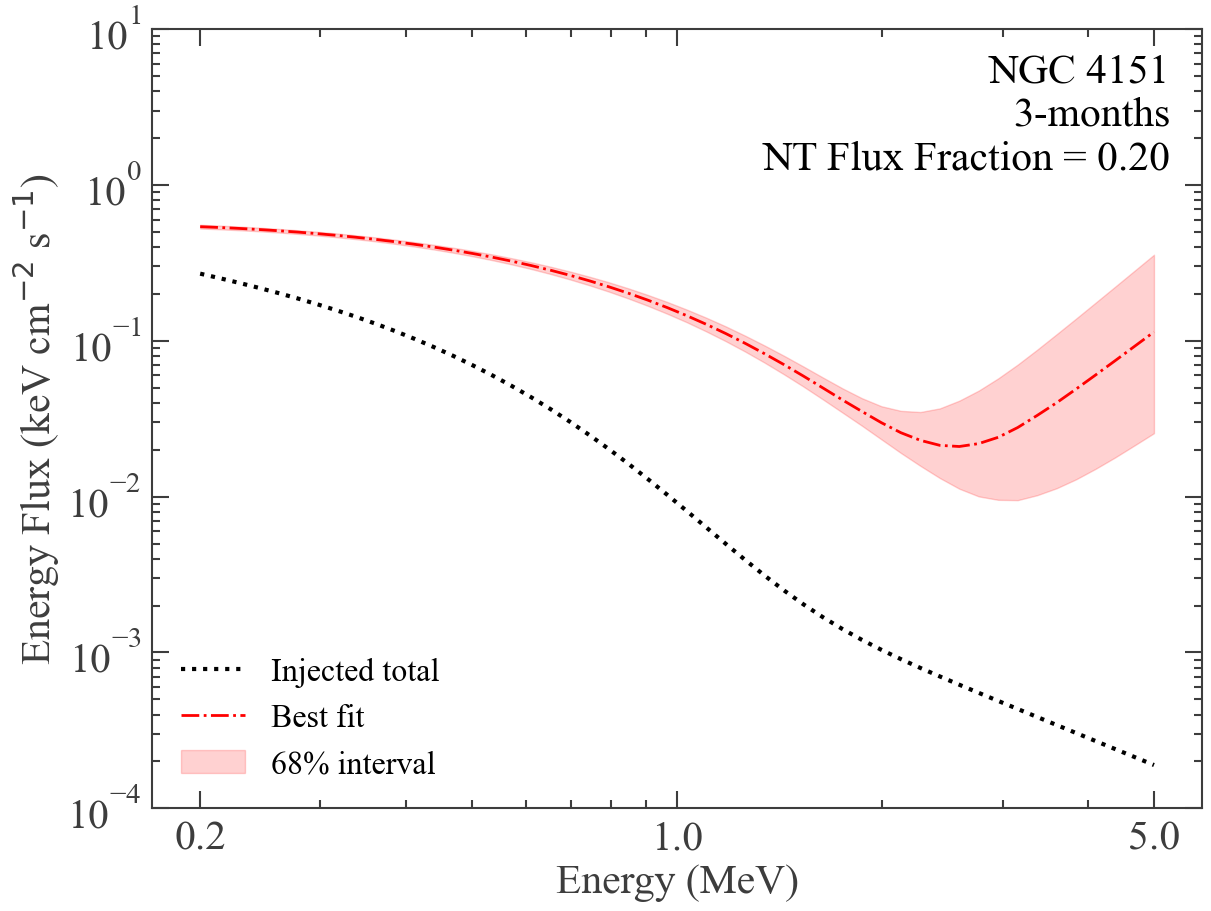

In [ ]:
FONT_SIZE = 30
plt.rcParams["agg.path.chunksize"] = 10000
plt.rcParams.update({"font.size": FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams.update({
    "font.weight": "550",
    "axes.titleweight": "550",
    "axes.labelweight": "550",
})


def style_axis(ax):
    ax.xaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", top=True, pad=8, labelsize=FONT_SIZE)
    ax.xaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", top=True, pad=8)
    ax.yaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", right=True, pad=8, labelsize=FONT_SIZE)
    ax.yaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", right=True, pad=8)
    ax.spines["right"].set_visible(True)
    ax.spines["top"].set_visible(True)


fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
style_axis(ax)

ax.plot(
    energy / 1000,
    energy * energy * flux_inj,
    color="black",
    ls=":",
    lw=3,
    label="Injected total",
)
ax.plot(
    energy / 1000,
    energy * energy * flux_median,
    color="red",
    lw=2,
    linestyle="dashdot",
    label="Best fit",
)
ax.fill_between(
    energy / 1000,
    energy * energy * flux_lo,
    energy * energy * flux_hi,
    alpha=0.18,
    color="red",
    label="68% interval",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1e-4, 10)
ax.xaxis.set_major_locator(mticker.FixedLocator([0.2, 1.0, 5.0]))
ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.2", "1.0", "5.0"]))
ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel(r"Energy Flux (keV cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)

thermal_flux = np.asarray([spectrum_inj_cpl.evaluate_at(e) for e in energy])
tail_flux = np.asarray([spectrum_inj_tail.evaluate_at(e) for e in energy])
thermal_energy_flux = np.trapezoid(energy * thermal_flux, energy)
tail_energy_flux = np.trapezoid(energy * tail_flux, energy)
energy_flux_ratio = tail_energy_flux / (thermal_energy_flux + tail_energy_flux)

ax.text(
    0.97,
    0.97,
    f"NGC 4151\n{exposure_months}-months\nNT Flux Fraction = {energy_flux_ratio:.2f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=FONT_SIZE,
    fontweight="550",
)
ax.legend(fontsize=23, loc="lower left", frameon=False)
plt.show()

Plot the fitted source plus background counts and the observed counts with the same publication-style formatting.

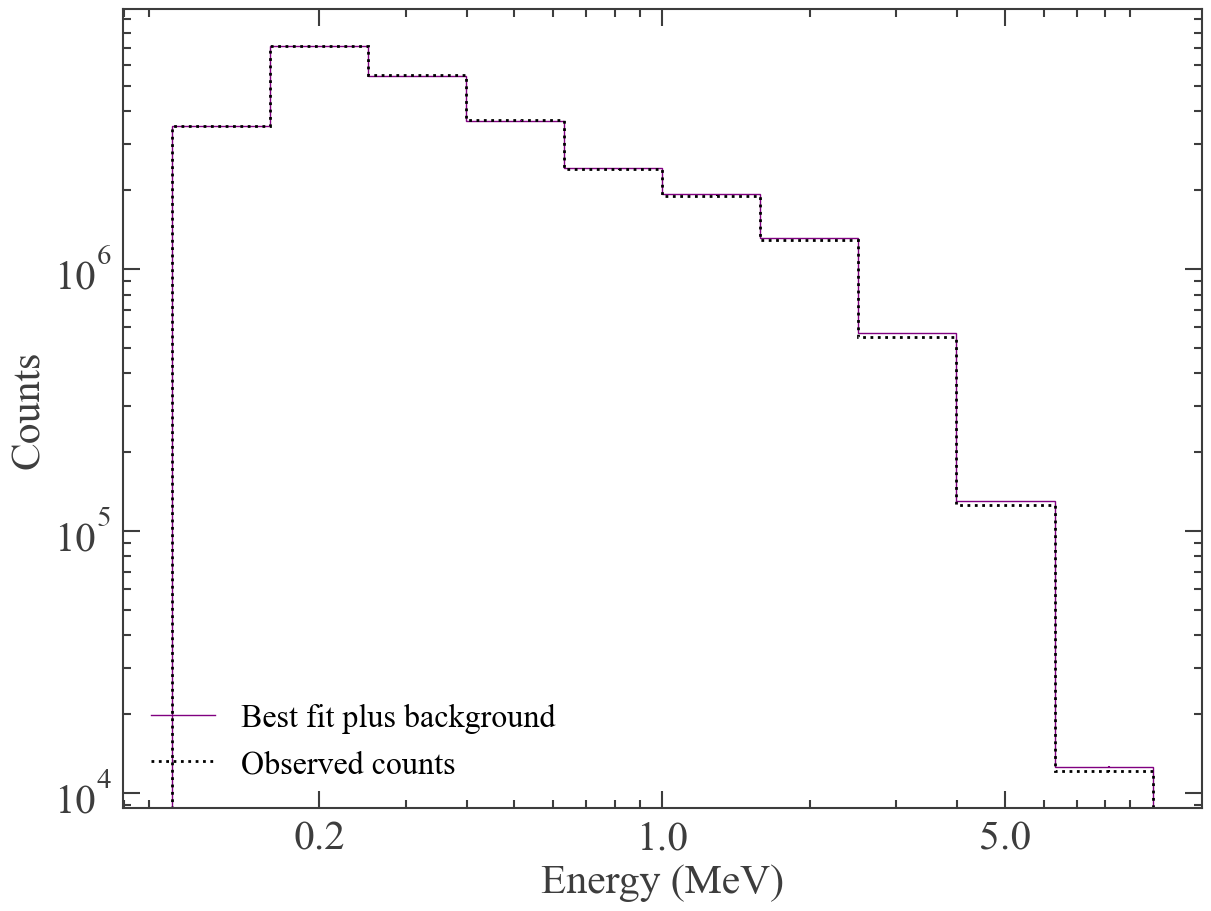

In [ ]:
expectation_bkg = bkg.expectation(copy=True)
model_counts = (
    expectation.project("Em").to_dense(copy=False).contents
    + expectation_bkg.project("Em").to_dense(copy=False).contents
)
data_counts = data.data.project("Em").to_dense(copy=False).contents

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
style_axis(ax)

ax.stairs(
    model_counts,
    binned_energy_edges / 1000,
    color="purple",
    label="Best fit plus background",
)
ax.errorbar(
    binned_energy / 1000,
    model_counts,
    yerr=np.sqrt(model_counts),
    color="purple",
    linewidth=0,
    elinewidth=1.5,
)
ax.stairs(
    data_counts,
    binned_energy_edges / 1000,
    color="black",
    ls=":",
    lw=2,
    label="Observed counts",
)
ax.errorbar(
    binned_energy / 1000,
    data_counts,
    yerr=np.sqrt(data_counts),
    color="black",
    linewidth=0,
    elinewidth=1.5,
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.xaxis.set_major_locator(mticker.FixedLocator([0.2, 1.0, 5.0]))
ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.2", "1.0", "5.0"]))
ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel("Counts", fontsize=FONT_SIZE)
ax.legend(fontsize=23, loc="lower left", frameon=False)
plt.show()